In [4]:
import numpy as np
import tensorflow as tf
from matplotlib import pyplot as plt
from jordanutils import *

rng = np.random.default_rng(seed=123)

Generowanie danych treningowych: 
- J - blok Jordana, gdzie `lam` oznacza wartości na przekątnej, a `block_size` oznacza liczbę "1" nad przekątną, np. dla `lam = 0`, `block_size = 3`: $J = \begin{bmatrix}
0 & 1 & 0 & 0 & 0 \\
0 & 0 & 1 & 0 & 0 \\
0 & 0 & 0 & 1 & 0 \\
0 & 0 & 0 & 0 & 0 \\
0 & 0 & 0 & 0 & 0 \\
\end{bmatrix}$. Używanie innych wartości własnych niż 0 nie wpływa na rezultaty. 
- S - losowa macierz przejścia
- do treningu idzie macierz $ X = SJS^{-1}$
- używałem macierzy $ 5 \times 5$. 
- dane składały się ze 100 000 macierzy, po 20 000 z każdej kategorii. 20% danych jest danymi testowymi. 20% z danych treningowych wydzielono na "valid set" do oceny postępu uczenia sieci neuronowej.

In [ ]:
def run(d, dataset_size = 20000):
    from sklearn.model_selection import train_test_split
    X, y = generate_testset(d, dataset_size)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=123)

    X_train = X_train.astype(np.float32)
    y_train = np.array(y_train)
    model1 = tf.keras.Sequential([
        tf.keras.layers.Flatten(input_shape=(d, d)),
        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.Dense(d)
    ])

    model1.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])
    
    early_stop = tf.keras.callbacks.EarlyStopping(
        monitor='val_accuracy', 
        patience=3,            
        restore_best_weights=True
    )

    model1.fit(
        X_train, y_train,
        epochs=50, 
        validation_split=0.2,   
        callbacks=[early_stop]
    )

  

    y_predicted = model1.predict(X_test)
    y_predicted = np.argmax(y_predicted, axis=1)

    return (y_test, y_predicted)

Epoch 1/50
2800/2800 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.3539 - loss: 1.5497 - val_accuracy: 0.3928 - val_loss: 1.3733
Epoch 2/50
2800/2800 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.4042 - loss: 1.3593 - val_accuracy: 0.4008 - val_loss: 1.3537
Epoch 3/50
2800/2800 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.4155 - loss: 1.3267 - val_accuracy: 0.4106 - val_loss: 1.3250
Epoch 4/50
2800/2800 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.4190 - loss: 1.3171 - val_accuracy: 0.4162 - val_loss: 1.3246
Epoch 5/50
2800/2800 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.4218 - loss: 1.3131 - val_accuracy: 0.4168 - val_loss: 1.3104
Epoch 6/50
2800/2800 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.4284 - loss: 1.3178 - val_accuracy: 0.4296 - val_loss: 1.2859
Epoch 7/50
2800/2800 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.4345 - loss: 1.3447 - val_accuracy: 0.4305 - val_loss: 1.2756
Epoch 8/50
2800/2800 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.4533 - loss: 1.2334 

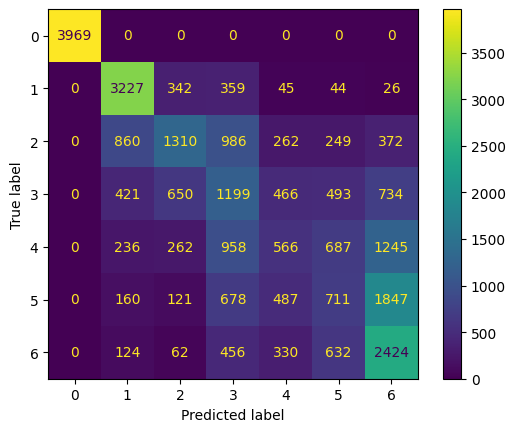

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3969
           1       0.64      0.80      0.71      4043
           2       0.48      0.32      0.39      4039
           3       0.26      0.30      0.28      3963
           4       0.26      0.14      0.19      3954
           5       0.25      0.18      0.21      4004
           6       0.36      0.60      0.45      4028

    accuracy                           0.48     28000
   macro avg       0.47      0.48      0.46     28000
weighted avg       0.47      0.48      0.46     28000



In [6]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

y_test, y_predicted = run(7)

cm = confusion_matrix(y_test, y_predicted)
ConfusionMatrixDisplay(cm).plot()
plt.show()

print(classification_report(y_test, y_predicted))

Label = liczba "1" nad przekątną w bloku Jordana. 

Sieć neuronowa bardzo dobrze radzi sobie z rozpoznawaniem macierzy diagonalizowalnych i niediagonalizowalnych. Największy kłopot ma z odróżnianiem wielkości klatek wymiaru >= 2. 

In [ ]:
# from sklearn.metrics import accuracy_score
# accuracy = []
# for d in range(4, 15):
#     y_true, y_predicted = run(d)
#     accuracy.append(accuracy_score(y_true=y_true, y_pred=y_predicted))

# plt.plot(range(4, 15), accuracy)
# plt.show()

Epoch 1/50


c:\Users\micha\Documents\Studia\Magisterka\venv\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1600/1600 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.5815 - loss: 0.8455 - val_accuracy: 0.6236 - val_loss: 0.7385
Epoch 2/50
1600/1600 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.6954 - loss: 0.6011 - val_accuracy: 0.6980 - val_loss: 0.6147
Epoch 3/50
1600/1600 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7245 - loss: 0.5639 - val_accuracy: 0.7502 - val_loss: 0.5023
Epoch 4/50
1600/1600 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7525 - loss: 0.4969 - val_accuracy: 0.7047 - val_loss: 0.6094
Epoch 5/50
1600/1600 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7588 - loss: 0.4915 - val_accuracy: 0.7723 - val_loss: 0.4749
Epoch 6/50
1600/1600 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7748 - loss: 0.4553 - val_accuracy: 0.7713 - val_loss: 0.4664
Epoch 7/50
1600/1600 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7833 - loss: 0.4430 - val_accuracy: 0.7838 - val_loss: 0.4438
Epoch 8/50
1600/1600 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7894 - loss: 0.4287 - val_accurac

c:\Users\micha\Documents\Studia\Magisterka\venv\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


2000/2000 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.4754 - loss: 1.1146 - val_accuracy: 0.5248 - val_loss: 0.9674
Epoch 2/50
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.5458 - loss: 0.9373 - val_accuracy: 0.5637 - val_loss: 0.9017
Epoch 3/50
 384/2000 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.5592 - loss: 0.8975

KeyboardInterrupt: 